# Percobaan 2
**Pipeline Preprocessing:** Grayscale → Resize → CLAHE → Median Filter → Normalisasi

---

Dataset terdiri dari 240 gambar asli (80 per kelas: *blast*, *blight*, *tungro*), kemudian diperbanyak dengan augmentasi (flip horizontal, flip vertikal, rotasi 90°) menjadi **960 gambar** (4× lipat, 320 gambar per kelas). Dari setiap gambar hasil preprocessing, diekstrak **42 fitur tekstur** (28 fitur GLCM pada 4 sudut + 14 fitur Wavelet Haar level 2), lalu disaring lewat feature selection berbasis korelasi menjadi **24 fitur final** yang dipakai untuk melatih tiga model: Random Forest, SVM, dan KNN.

Percobaan 2 menghasilkan performa terbaik di antara seluruh percobaan, dengan Random Forest mencapai **akurasi testing 96.88%**. Berikut penjelasan rinci tiap bagian.

---

## 1. Import Library

Mengimpor seluruh library yang dibutuhkan:

| Library | Kegunaan |
|---|---|
| `cv2` | Pemrosesan gambar (baca, resize, flip, CLAHE, median filter) |
| `numpy / pandas` | Manipulasi array dan tabel data |
| `sklearn` | Pembagian data, pelatihan model (RF, SVM, KNN), dan evaluasi |
| `skimage` | Ekstraksi fitur GLCM |
| `scipy` | Perhitungan entropi dan konvolusi wavelet Haar manual |
| `matplotlib / seaborn` | Visualisasi grafik dan heatmap |

In [45]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from scipy.ndimage import convolve
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

## 2. Data Loading

Dataset berisi gambar daun padi yang diorganisasi dalam subfolder per kelas penyakit:

```
PROJECT-PCD-34/
├── dataset/
│   ├── blast/
│   │   ├── image1.jpg
│   │   └── ...
│   ├── blight/
│   │   ├── image1.jpg
│   │   └── ...
│   └── tungro/
│       ├── image1.jpg
│       └── ...
└── Percobaan_1.ipynb
```

Setiap gambar akan:
1. Dibaca dengan `cv.imread()`
2. Dikonversi ke **grayscale** (`COLOR_BGR2GRAY`)
3. Di-*resize* ke **256×256 piksel**

> **Catatan:** Dataset ini memiliki **3 kelas** penyakit daun padi: `blast`, `blight`, dan `tungro`.

In [46]:
DATASET_PATH = "dataset"
TARGET_SIZE  = (256, 256)
KELAS_VALID  = ['blast', 'blight', 'tungro']

data      = []
labels    = []
file_name = []

for sub_folder in sorted(os.listdir(DATASET_PATH)):
    sub_folder_path = os.path.join(DATASET_PATH, sub_folder)

    if not os.path.isdir(sub_folder_path):
        continue
    if sub_folder not in KELAS_VALID:
        print(f"⚠️  Folder '{sub_folder}' dilewati (bukan kelas dataset)")
        continue

    sub_folder_files = os.listdir(sub_folder_path)
    print(f"📂 Memuat kelas '{sub_folder}': {len(sub_folder_files)} file...")

    for filename in sub_folder_files:
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            print(f"   ⚠️  Gagal membaca: {filename}")
            continue
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = cv.resize(img, TARGET_SIZE, interpolation=cv.INTER_AREA)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data      = np.array(data, dtype=np.uint8)
labels    = np.array(labels)

print()
print(f"✅ Total gambar berhasil dimuat: {len(data)}")
print(f"   Ukuran gambar : {data[0].shape}")
print(f"   Tipe data     : {data.dtype}")
print(f"📊 Distribusi per kelas:")
for kelas in KELAS_VALID:
    jumlah = np.sum(labels == kelas)
    print(f"   {kelas:10s}: {jumlah} gambar")

📂 Memuat kelas 'blast': 80 file...
📂 Memuat kelas 'blight': 80 file...
📂 Memuat kelas 'tungro': 80 file...

✅ Total gambar berhasil dimuat: 240
   Ukuran gambar : (256, 256)
   Tipe data     : uint8
📊 Distribusi per kelas:
   blast     : 80 gambar
   blight    : 80 gambar
   tungro    : 80 gambar


### Visualisasi Sampel per Kelas

Menampilkan satu sampel gambar grayscale untuk masing-masing kelas.

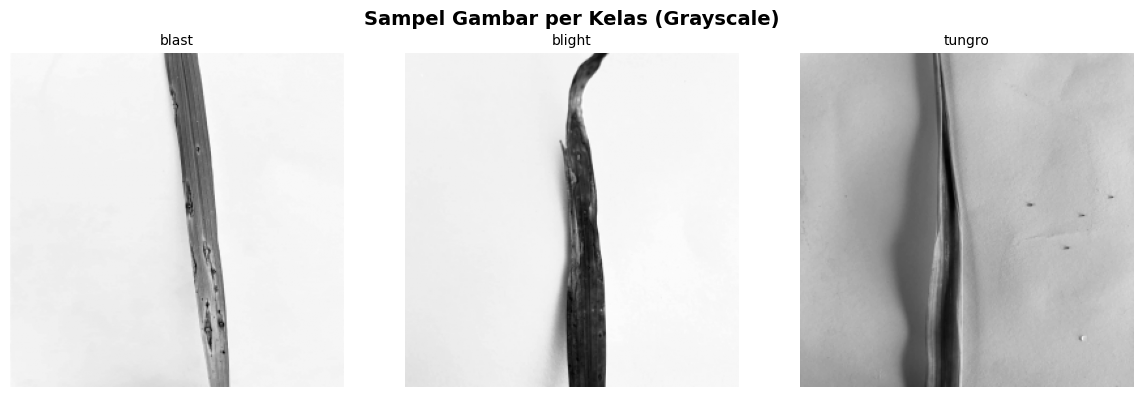

In [47]:
unique_labels = np.unique(labels)
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))
fig.suptitle("Sampel Gambar per Kelas (Grayscale)", fontsize=14, fontweight='bold')

for ax, kelas in zip(axes, unique_labels):
    idx = np.where(labels == kelas)[0][0]
    ax.imshow(data[idx], cmap='gray')
    ax.set_title(kelas, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Data Augmentation

Augmentasi dilakukan untuk memperbanyak variasi data latih agar model lebih *robust*.  
Setiap gambar asli menghasilkan **3 gambar baru**, sehingga total data bertambah **4×**.

| Teknik | Fungsi OpenCV | Keterangan |
|---|---|---|
| Flip Horizontal | `cv.flip(img, 1)` | Membalik gambar secara horizontal |
| Flip Vertikal | `cv.flip(img, 0)` | Membalik gambar secara vertikal |
| Rotasi 90° | `cv.rotate(..., ROTATE_90_CLOCKWISE)` | Memutar gambar 90° searah jarum jam |

**Hasil yang diharapkan:** 240 gambar → **960 gambar**

In [48]:
data_augmented      = list(data)
labels_augmented    = list(labels)
file_name_augmented = list(file_name)

for i in range(len(data)):
    img   = data[i]
    label = labels[i]
    fname = file_name[i]
    name, ext = os.path.splitext(fname)

    # Flip Horizontal
    flipped_h = cv.flip(img, 1)
    data_augmented.append(flipped_h)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_flipH{ext}")

    # Flip Vertikal
    flipped_v = cv.flip(img, 0)
    data_augmented.append(flipped_v)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_flipV{ext}")

    # Rotasi 90°
    rotated = cv.rotate(img, cv.ROTATE_90_CLOCKWISE)
    data_augmented.append(rotated)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_rot90{ext}")

data_augmented      = np.array(data_augmented, dtype=object)
labels_augmented    = np.array(labels_augmented)
file_name_augmented = np.array(file_name_augmented)

print(f"Data sebelum augmentasi : {len(data)}")
print(f"Data setelah augmentasi : {len(data_augmented)}")

Data sebelum augmentasi : 240
Data setelah augmentasi : 960


## 4. Preprocessing — Percobaan 2

### Pipeline: Grayscale → Resize → CLAHE → Median Filter → Normalisasi

| Langkah | Fungsi | Tujuan |
|---|---|---|
| **CLAHE** | `cv.createCLAHE` | Meningkatkan kontras lokal secara adaptif, menonjolkan detail tekstur lesi |
| **Median Filter** | `cv.medianBlur` | Menghilangkan noise *salt-and-pepper* sambil mempertahankan tepi (*edge*) |
| **Normalisasi** | `/ 255.0` | Mengubah rentang nilai piksel ke [0, 1], lalu dikembalikan ke `uint8` |

> **CLAHE** *(Contrast Limited Adaptive Histogram Equalization)* bekerja dengan membagi gambar menjadi tile-tile kecil, kemudian melakukan ekualisasi histogram lokal dengan pembatasan kontras (`clipLimit`) untuk mencegah penguatan noise berlebihan.

In [49]:
def resize(image, target_size=(512, 512)):
    return cv.resize(image, target_size, interpolation=cv.INTER_AREA)

def normalisasi(image):
    return image.astype(np.float32) / 255.0

def clahe(image):
    tile_h, tile_w = 8, 8
    clip_limit = 2.0

    h, w = image.shape
    th = h // tile_h
    tw = w // tile_w

    hasil = np.zeros_like(image, dtype=np.uint8)

    for row in range(tile_h):
        for col in range(tile_w):
            y1, y2 = row * th, (row + 1) * th
            x1, x2 = col * tw, (col + 1) * tw
            tile = image[y1:y2, x1:x2]

            hist = np.zeros(256, dtype=np.int32)
            for i in range(th):
                for j in range(tw):
                    hist[tile[i, j]] += 1

            total_pixels = th * tw
            clip_val = int(clip_limit * total_pixels / 256)

            clipped = 0
            for i in range(256):
                if hist[i] > clip_val:
                    clipped += hist[i] - clip_val
                    hist[i] = clip_val

            redistribute = clipped // 256
            for i in range(256):
                hist[i] += redistribute

            cdf = np.zeros(256, dtype=np.int64)
            cdf[0] = hist[0]
            for i in range(1, 256):
                cdf[i] = cdf[i - 1] + hist[i]

            cdf_min = 0
            for i in range(256):
                if cdf[i] > 0:
                    cdf_min = cdf[i]
                    break

            lut = np.zeros(256, dtype=np.uint8)
            for i in range(256):
                val = (cdf[i] - cdf_min) * 255 // (total_pixels - cdf_min)
                if val < 0:
                    lut[i] = 0
                elif val > 255:
                    lut[i] = 255
                else:
                    lut[i] = val


            for i in range(th):
                for j in range(tw):
                    hasil[y1 + i, x1 + j] = lut[tile[i, j]]

    return hasil

def median_filter(image, ksize=3):
    h, w = image.shape
    pad = ksize // 2

    output = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):

            pixels = []
            for m in range(-pad, pad + 1):
                for n in range(-pad, pad + 1):

                    y = i + m
                    x = j + n

                    # Padding manual
                    if y < 0:
                        y = 0
                    elif y >= h:
                        y = h - 1

                    if x < 0:
                        x = 0
                    elif x >= w:
                        x = w - 1

                    pixels.append(int(image[y, x]))

            # Bubble Sort
            for a in range(len(pixels)):
                for b in range(len(pixels) - a - 1):
                    if pixels[b] > pixels[b + 1]:
                        temp = pixels[b]
                        pixels[b] = pixels[b + 1]
                        pixels[b + 1] = temp

            # Ambil median
            median = pixels[len(pixels) // 2]

            output[i, j] = median

    return output

def prepro2(image, target_size=(512, 512)):
    img = image.astype(np.uint8)
    img = clahe(img)
    img = median_filter(img, ksize=3)
    img = normalisasi(img)
    img_uint8 = (img * 255).astype(np.uint8)
    return img_uint8

In [50]:
dataPreprocessed = []

for i in range(len(data_augmented)):
    img_prep = prepro2(data_augmented[i])
    dataPreprocessed.append(img_prep)

dataPreprocessed = np.array(dataPreprocessed)

print(f"   Jumlah gambar    : {len(dataPreprocessed)}")
print(f"   Ukuran gambar    : {dataPreprocessed[0].shape}")
print(f"   Tipe data        : {dataPreprocessed[0].dtype}")
print(f"   Nilai min / max  : {dataPreprocessed[0].min()} / {dataPreprocessed[0].max()}")

   Jumlah gambar    : 960
   Ukuran gambar    : (256, 256)
   Tipe data        : uint8
   Nilai min / max  : 26 / 240


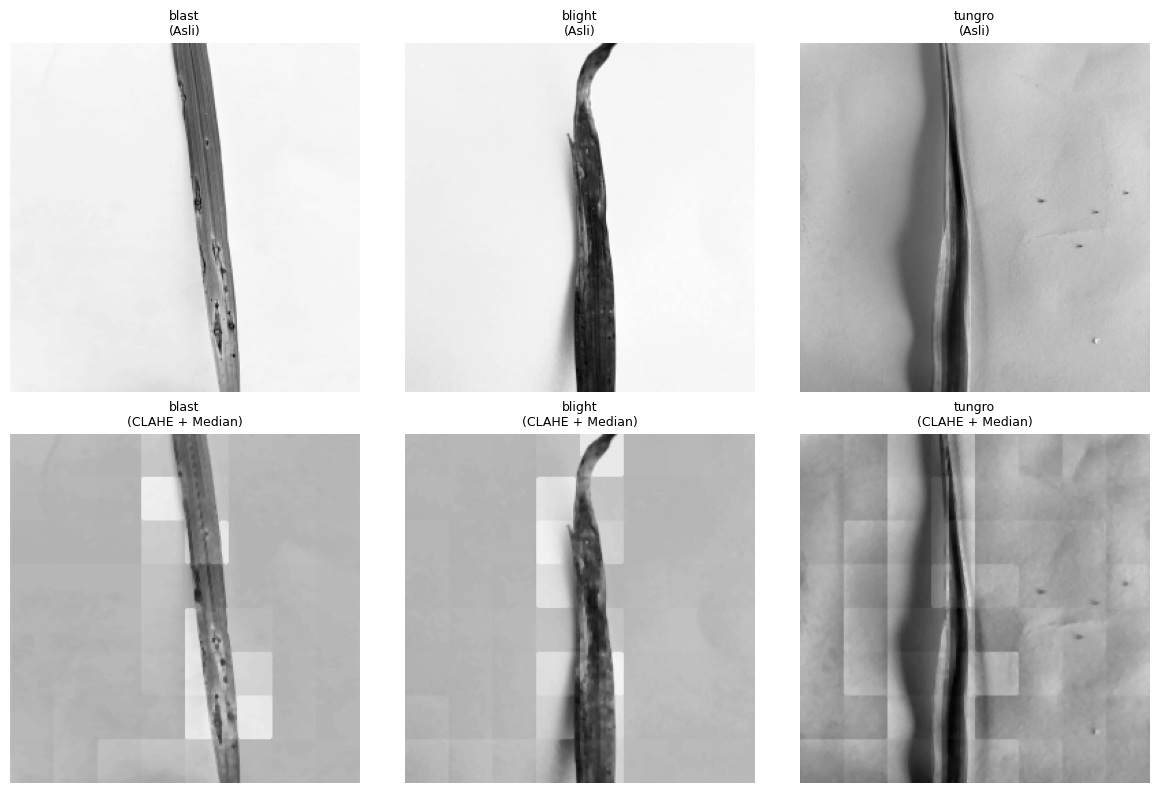

In [51]:
unique_labels = np.unique(labels_augmented)
n_kelas = len(unique_labels)

fig, axes = plt.subplots(2, n_kelas, figsize=(4 * n_kelas, 8))

for col, kelas in enumerate(unique_labels):
    idx = np.where(labels_augmented == kelas)[0][0]

    # Baris 1: gambar asli
    axes[0, col].imshow(data_augmented[idx].astype(np.uint8), cmap='gray')
    axes[0, col].set_title(f"{kelas}\n(Asli)", fontsize=9)
    axes[0, col].axis('off')

    # Baris 2: hasil preprocessing
    axes[1, col].imshow(dataPreprocessed[idx], cmap='gray', vmin=0, vmax=255)
    axes[1, col].set_title(f"{kelas}\n(CLAHE + Median)", fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

## 5. Ekstraksi Fitur GLCM

In [52]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan: 0, 45, 90, atau 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [53]:
Derajat0   = []
Derajat45  = []
Derajat90  = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(dataPreprocessed)}")

print()
print(f" Matriks GLCM selesai dihitung untuk {len(dataPreprocessed)} gambar!")

   Progress: 100/960
   Progress: 200/960
   Progress: 300/960
   Progress: 400/960
   Progress: 500/960
   Progress: 600/960
   Progress: 700/960
   Progress: 800/960
   Progress: 900/960

 Matriks GLCM selesai dihitung untuk 960 gambar!


In [54]:
# EKSTRAKSI FITUR GLCM

Kontras0, Kontras45, Kontras90, Kontras135                     = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135          = [], [], [], []
entropy0, entropy45, entropy90, entropy135                      = [], [], [], []
ASM0, ASM45, ASM90, ASM135                                      = [], [], [], []
energy0, energy45, energy90, energy135                          = [], [], [], []
correlation0, correlation45, correlation90, correlation135      = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

## 6. Ekstraksi Fitur Wavelet (Haar — Implementasi Manual)

In [55]:
HAAR_LP = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HAAR_HP = np.array([1/np.sqrt(2), -1/np.sqrt(2)])

def haar_dwt2d_level1(image):
    img = image.astype(np.float32)

    # Konvolusi baris
    from scipy.ndimage import convolve1d
    L_row = convolve1d(img,    HAAR_LP, axis=1, mode='wrap')[:, ::2]
    H_row = convolve1d(img,    HAAR_HP, axis=1, mode='wrap')[:, ::2]

    # Konvolusi kolom
    LL = convolve1d(L_row, HAAR_LP, axis=0, mode='wrap')[::2, :]
    LH = convolve1d(L_row, HAAR_HP, axis=0, mode='wrap')[::2, :]
    HL = convolve1d(H_row, HAAR_LP, axis=0, mode='wrap')[::2, :]
    HH = convolve1d(H_row, HAAR_HP, axis=0, mode='wrap')[::2, :]

    return LL, LH, HL, HH


def ekstraksi_wavelet(image, level=2):
    fitur = []
    current = image.astype(np.float32)

    for lv in range(1, level + 1):
        LL, LH, HL, HH = haar_dwt2d_level1(current)

        if lv == level:
            fitur.append(np.mean(LL))
            fitur.append(np.std(LL))

        # Detail sub-bands setiap level
        fitur.append(np.mean(LH));  fitur.append(np.std(LH))
        fitur.append(np.mean(HL));  fitur.append(np.std(HL))
        fitur.append(np.mean(HH));  fitur.append(np.std(HH))

        # LL menjadi input level berikutnya
        current = LL

    return fitur

dummy = np.random.randint(0, 255, (256, 256), dtype=np.uint8)
sample_wav = ekstraksi_wavelet(dummy, level=2)
print("   Wavelet    : Haar (manual, tanpa pywt)")
print("   Library    : NumPy + SciPy (scipy.ndimage.convolve1d)")
print("   Level      : 2")
print("   Sub-bands  : LL (level 2), LH/HL/HH (level 1 & 2) — mean & std")
print(f"   Jumlah fitur wavelet per gambar: {len(sample_wav)}")

   Wavelet    : Haar (manual, tanpa pywt)
   Library    : NumPy + SciPy (scipy.ndimage.convolve1d)
   Level      : 2
   Sub-bands  : LL (level 2), LH/HL/HH (level 1 & 2) — mean & std
   Jumlah fitur wavelet per gambar: 14


In [56]:
wavelet_features = []
for i in range(len(dataPreprocessed)):
    wav_feat = ekstraksi_wavelet(dataPreprocessed[i], level=2)
    wavelet_features.append(wav_feat)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(dataPreprocessed)}")

wavelet_features = np.array(wavelet_features)
print()
print(f"   Ekstraksi Wavelet selesai!")
print(f"   Shape fitur Wavelet: {wavelet_features.shape}")
print(f"   Keterangan kolom   : [LL_mean, LL_std, LH_L2_mean, LH_L2_std, HL_L2_mean, HL_L2_std, HH_L2_mean, HH_L2_std, LH_L1_mean, LH_L1_std, HL_L1_mean, HL_L1_std, HH_L1_mean, HH_L1_std]")

   Progress: 100/960
   Progress: 200/960
   Progress: 300/960
   Progress: 400/960
   Progress: 500/960
   Progress: 600/960
   Progress: 700/960
   Progress: 800/960
   Progress: 900/960

   Ekstraksi Wavelet selesai!
   Shape fitur Wavelet: (960, 14)
   Keterangan kolom   : [LL_mean, LL_std, LH_L2_mean, LH_L2_std, HL_L2_mean, HL_L2_std, HH_L2_mean, HH_L2_std, LH_L1_mean, LH_L1_std, HL_L1_mean, HL_L1_std, HH_L1_mean, HH_L1_std]


## 7. Simpan Hasil Ekstraksi ke CSV

In [57]:
wav_col_names = (
    ['Wav_LL_mean', 'Wav_LL_std'] +
    ['Wav_LH_L2_mean', 'Wav_LH_L2_std',
     'Wav_HL_L2_mean', 'Wav_HL_L2_std',
     'Wav_HH_L2_mean', 'Wav_HH_L2_std'] +
    ['Wav_LH_L1_mean', 'Wav_LH_L1_std',
     'Wav_HL_L1_mean', 'Wav_HL_L1_std',
     'Wav_HH_L1_mean', 'Wav_HH_L1_std']
)

dataTable = {
    'Filename' : file_name_augmented,
    'Label'    : labels_augmented,
    'Contrast0': Kontras0,     'Contrast45': Kontras45,     'Contrast90': Kontras90,     'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0,      'Entropy45': entropy45,      'Entropy90': entropy90,      'Entropy135': entropy135,
    'ASM0': ASM0,              'ASM45': ASM45,              'ASM90': ASM90,              'ASM135': ASM135,
    'Energy0': energy0,        'Energy45': energy45,        'Energy90': energy90,        'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

for j, col in enumerate(wav_col_names):
    dataTable[col] = wavelet_features[:, j]

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')
print(f"   Shape DataFrame: {hasilEkstrak.shape}")
hasilEkstrak.head()

   Shape DataFrame: (960, 44)


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Wav_HL_L2_mean,Wav_HL_L2_std,Wav_HH_L2_mean,Wav_HH_L2_std,Wav_LH_L1_mean,Wav_LH_L1_std,Wav_HL_L1_mean,Wav_HL_L1_std,Wav_HH_L1_mean,Wav_HH_L1_std
0,IMG_0448.jpg,blast,66.516575,64.759246,11.481618,81.579823,0.816238,0.761865,0.830238,0.757695,...,-0.000397,1.551942,719.93070,92.89598,-0.132019,5.638540,-0.444031,20.988400,-0.028259,4.720187
1,IMG_0535.jpg,blast,43.643444,50.764614,6.086596,45.113972,0.824240,0.762649,0.816397,0.753364,...,-0.003784,0.944885,684.08230,125.64434,-1.265259,3.921095,0.001831,19.603140,0.003662,2.339661
2,IMG_0536.jpg,blast,79.340885,92.701269,15.501547,86.120784,0.627787,0.522371,0.662346,0.548777,...,0.007355,1.687353,575.86237,131.02608,-1.929870,6.440408,-0.725403,22.745510,-0.026428,4.397104
3,IMG_0541.jpg,blast,68.008134,84.304775,16.492892,72.326244,0.618999,0.534559,0.643561,0.511200,...,0.014465,1.756103,561.25770,133.09192,-1.551148,8.272208,0.565064,23.473738,0.014038,4.489342
4,IMG_0543.jpg,blast,60.473744,69.790742,13.721783,68.856486,0.606501,0.526960,0.654657,0.498394,...,-0.006104,1.542121,571.60240,130.95137,-0.116089,8.611052,-0.686280,19.269722,0.014160,3.680017


## 8. Feature Selection (Korelasi)

In [58]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns   = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new  = hasilEkstrak[select]
y      = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : {hasilEkstrak.drop(columns=['Label','Filename']).shape[1]}")
print(f"Fitur setelah seleksi : {x_new.shape[1]}")
print(f"Fitur yang dipilih    : {list(select)}")

Fitur sebelum seleksi : 42
Fitur setelah seleksi : 24
Fitur yang dipilih    : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'ASM0', 'Energy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135', 'Wav_LL_mean', 'Wav_LH_L2_mean', 'Wav_LH_L2_std', 'Wav_HL_L2_mean', 'Wav_HL_L2_std', 'Wav_HH_L2_mean', 'Wav_HH_L2_std', 'Wav_HL_L1_mean', 'Wav_HH_L1_mean', 'Wav_HH_L1_std']


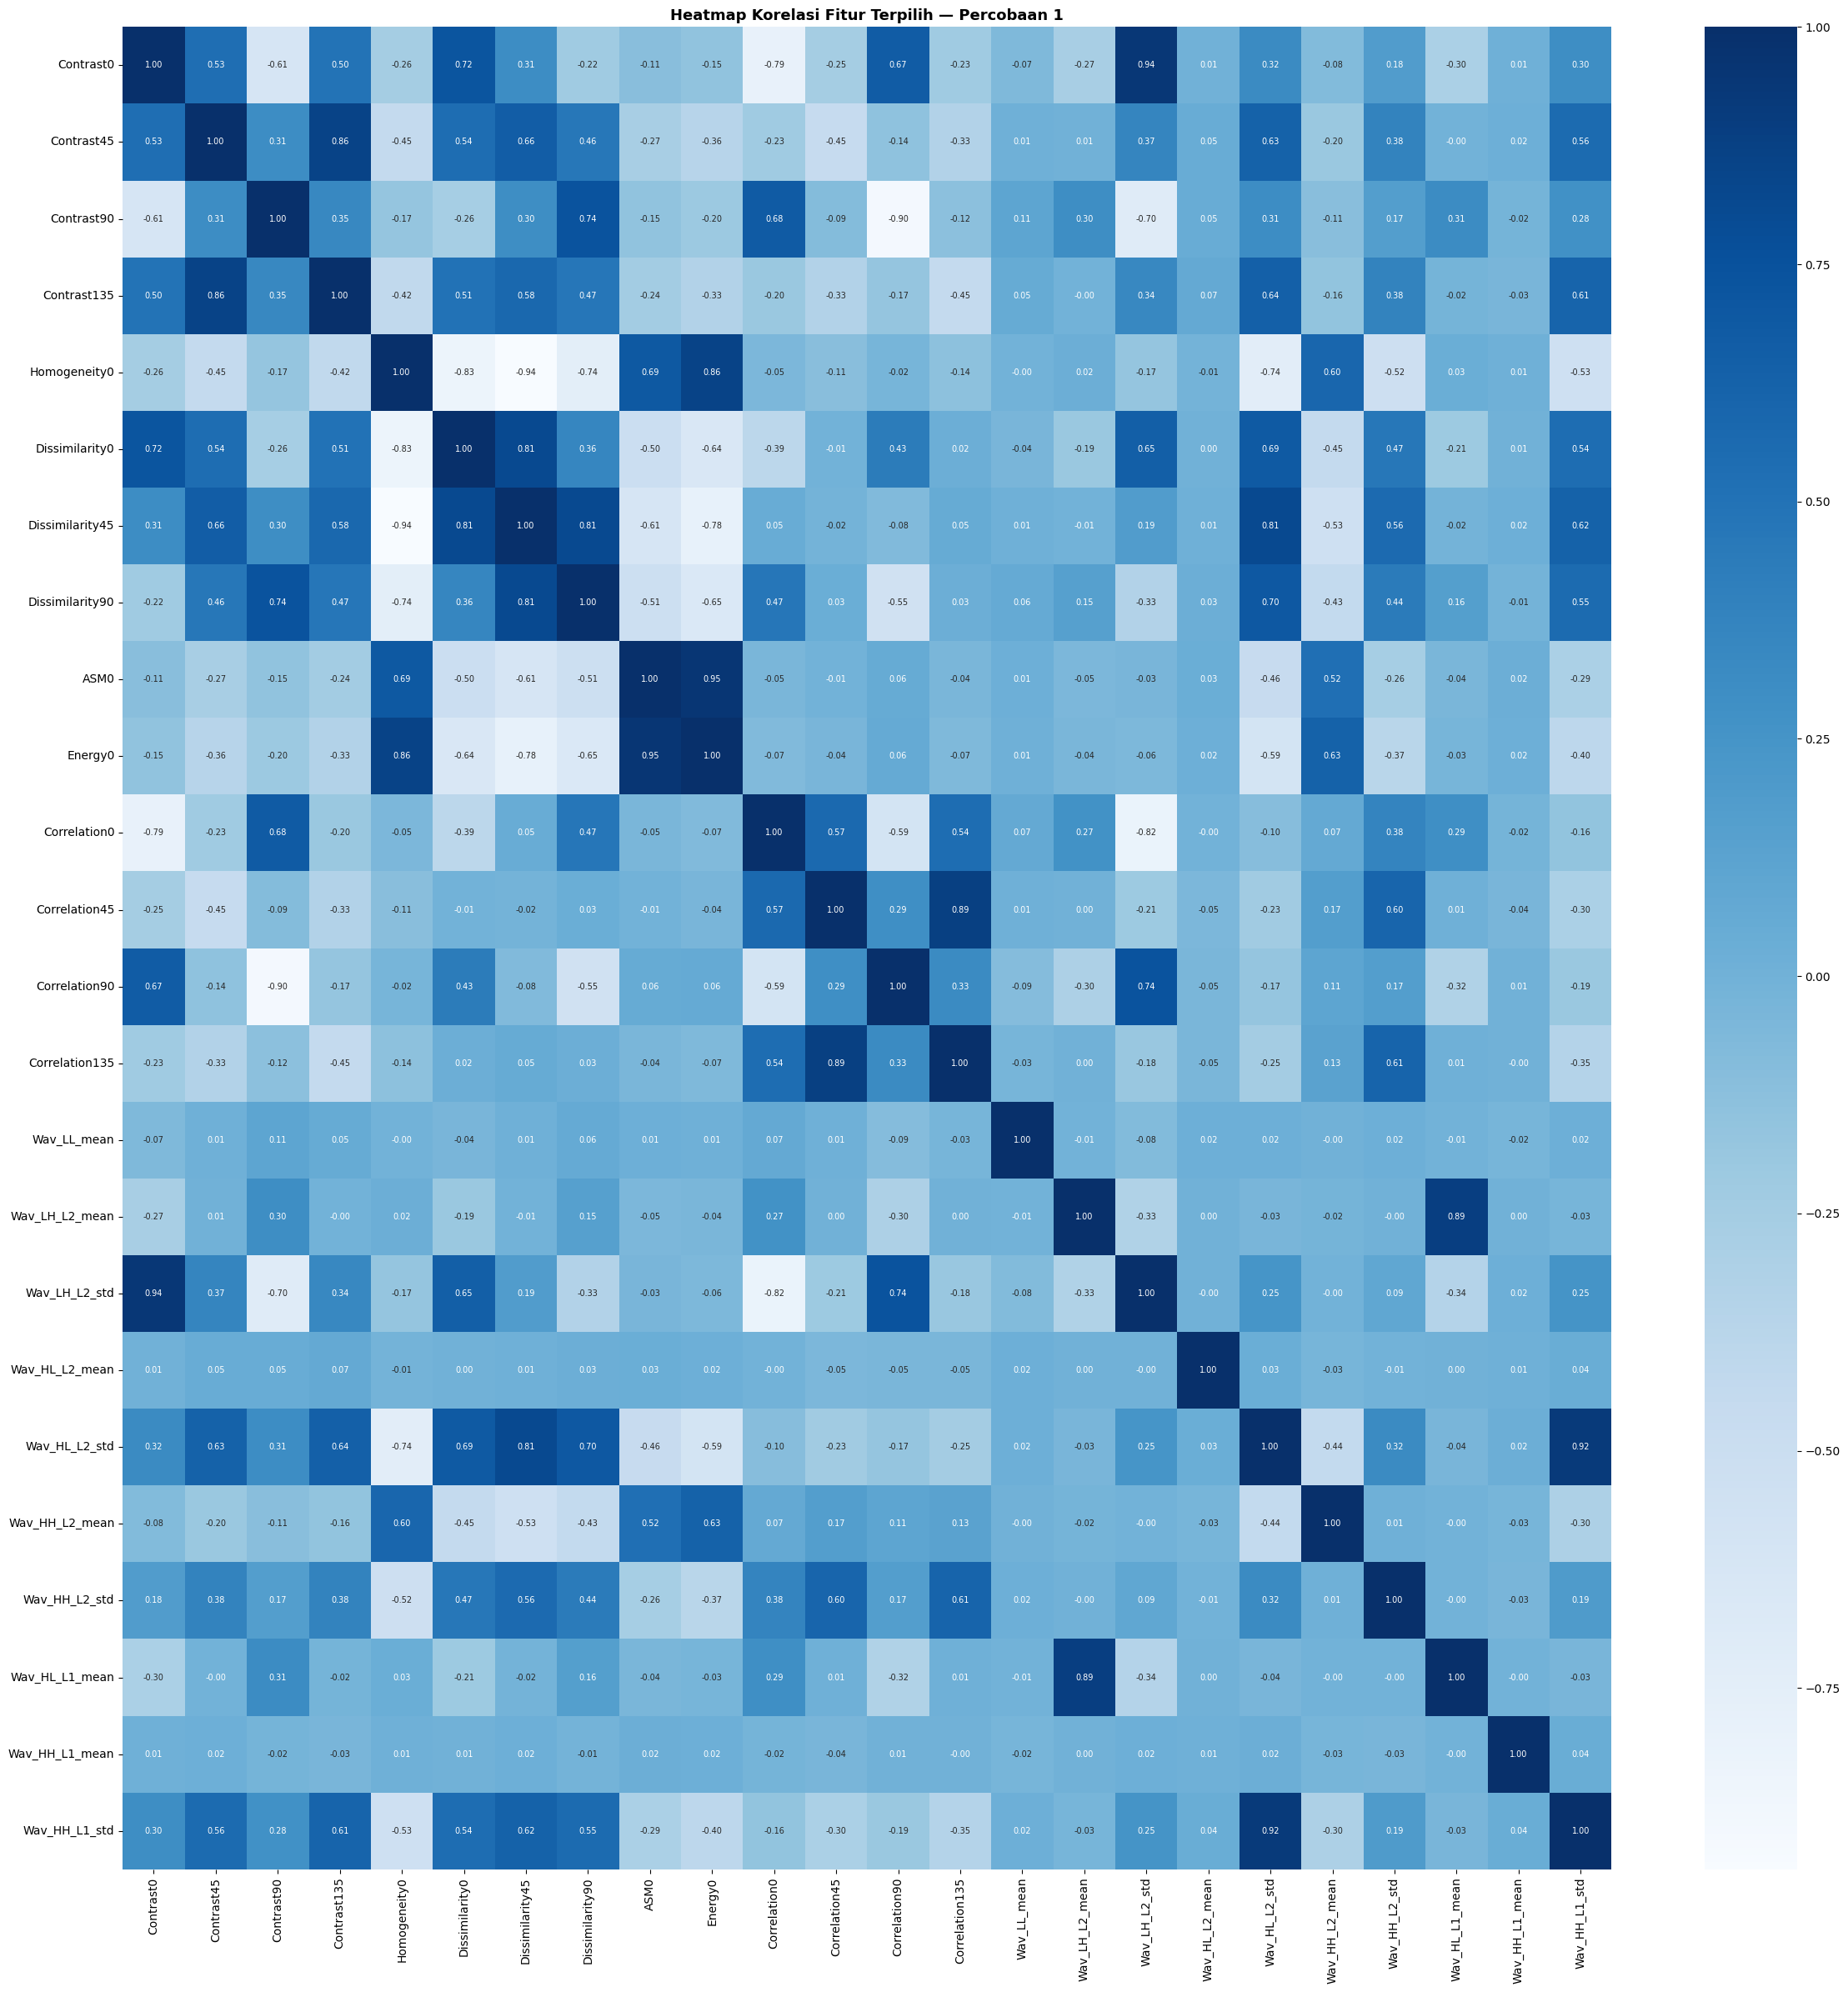

In [59]:
plt.figure(figsize=(max(12, x_new.shape[1]), max(10, x_new.shape[1])))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f",
            annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Terpilih — Percobaan 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Logika ini menghitung **matriks korelasi Pearson** antar seluruh 42 fitur numerik, lalu membuang fitur yang **berkorelasi sangat tinggi** (≥ 0.95, baik positif maupun negatif karena dipakai `abs()`) dengan fitur lain yang sudah dipertahankan. Setiap pasangan fitur diperiksa hanya sekali (`j` mulai dari `i+1`) supaya tidak menghapus dua fitur sekaligus dari pasangan yang sama — yang dipertahankan adalah fitur dengan indeks kolom lebih awal (`i`), yang dibuang adalah fitur dengan indeks lebih besar (`j`).

GLCM dihitung pada 4 sudut (0°, 45°, 90°, 135°) untuk 7 properti tekstur (Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy, Correlation) — totalnya 28 fitur. Karena daun pada gambar cenderung punya orientasi tekstur yang relatif mirip ke segala arah (atau karena ASM dan Energy secara matematis saling berkaitan — Energy adalah akar dari ASM), banyak fitur ini **redundan**. Fitur yang redundan:

- Tidak menambah informasi baru bagi model, hanya menambah dimensi.
- Bisa menyebabkan **multikolinearitas**, yang merusak interpretasi koefisien pada model linear dan dapat membuat KNN/SVM lebih sensitif terhadap noise karena jarak antar sampel didominasi oleh fitur yang "diduplikasi" beberapa kali.
- Memperlambat training tanpa manfaat akurasi yang sepadan.

### Hasil seleksi

| Kategori | Sebelum | Sesudah |
|---|---|---|
| Total fitur | 42 | 24 |

Fitur yang **bertahan** (24 fitur):
```
Contrast0, Contrast45, Contrast90, Contrast135,
Homogeneity0, Dissimilarity0, Dissimilarity45, Dissimilarity90,
ASM0, Energy0, Correlation0, Correlation45, Correlation90, Correlation135,
Wav_LL_mean, Wav_LH_L2_mean, Wav_LH_L2_std, Wav_HL_L2_mean, Wav_HL_L2_std,
Wav_HH_L2_mean, Wav_HH_L2_std, Wav_HL_L1_mean, Wav_HH_L1_mean, Wav_HH_L1_std
```

Hal yang menarik untuk diperhatikan:
- **Contrast** bertahan di keempat sudut (0°, 45°, 90°, 135°) — artinya kontras tekstur cukup bervariasi antar arah, jadi tidak redundan satu sama lain.
- **Homogeneity, Dissimilarity, Entropy** hanya bertahan di sebagian sudut — sisanya terbuang karena nilainya sangat berkorelasi dengan sudut lain (wajar, karena Homogeneity dan Dissimilarity secara konsep saling berkebalikan/berkaitan erat).
- **ASM dan Energy** masing-masing hanya bertahan satu (ASM0, Energy0) dari 8 kemungkinan (ASM/Energy × 4 sudut) — ini mengonfirmasi bahwa ASM dan Energy sangat berkorelasi satu sama lain (Energy = √ASM) sehingga banyak terbuang.
- Hampir seluruh fitur **wavelet** bertahan, menunjukkan fitur wavelet relatif tidak redundan terhadap fitur GLCM maupun sesamanya — ini sejalan dengan ide awal project, di mana wavelet menambahkan informasi multi-resolusi yang tidak ditangkap GLCM.

### Heatmap korelasi fitur terpilih

Heatmap yang ditampilkan menunjukkan korelasi antar 24 fitur yang **sudah lolos seleksi**. Karena seleksi sudah membuang pasangan dengan korelasi ≥ 0.95, wajar jika sebagian besar sel di heatmap berwarna lebih terang (korelasi sedang/rendah), meski ada beberapa sel masih cukup gelap (korelasi 0.7–0.9) — ini terjadi karena threshold yang dipakai (0.95) cukup longgar, sehingga fitur yang berkorelasi "tinggi tapi belum ekstrem" tetap dipertahankan. Ini wajar dan bukan kesalahan, karena tujuan seleksi bukan menghilangkan semua korelasi, hanya redundansi paling parah.

## 9. Pembagian Data (Train / Test)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print()

print("Distribusi kelas — Training:")
print(pd.Series(y_train).value_counts().to_string())
print()
print("Distribusi kelas — Testing:")
print(pd.Series(y_test).value_counts().to_string())

   X_train : (768, 24)
   X_test  : (192, 24)

Distribusi kelas — Training:
Label
tungro    256
blight    256
blast     256

Distribusi kelas — Testing:
Label
blast     64
blight    64
tungro    64


- **`test_size=0.2`** → 20% data dialokasikan untuk testing, 80% untuk training.
- **`stratify=y`** → pembagian dilakukan secara proporsional per kelas, sehingga distribusi kelas di train dan test tetap seimbang (bukan acak murni yang bisa menghasilkan kelas yang tidak rata).
- **`random_state=42`** → memastikan hasil split bisa direproduksi (selalu sama setiap kali kode dijalankan ulang).

### Hasil split

| Set | Jumlah Sampel | Fitur | Distribusi per kelas |
|---|---|---|---|
| Train | 768 | 24 | blast 256, blight 256, tungro 256 |
| Test | 192 | 24 | blast 64, blight 64, tungro 64 |

Distribusi ini **seimbang sempurna** (masing-masing kelas tepat 80% dan 20%) karena `stratify=y` bekerja pada dataset yang dari awal sudah seimbang (240 gambar asli × 4 hasil augmentasi = 960, dengan 320 per kelas, lalu dibagi 80:20 = 256:64 per kelas). Keseimbangan ini penting karena tanpanya, metrik seperti accuracy bisa menyesatkan (model bisa "curang" dengan selalu menebak kelas mayoritas).

### note

Augmentasi (flip H, flip V, rotasi 90°) dilakukan **sebelum** train/test split. Ini berarti gambar asli dan versi augmentasinya (yang berasal dari gambar yang sama) bisa saja terpisah — satu masuk ke train, satu masuk ke test. Karena flip/rotasi adalah transformasi geometris yang tidak mengubah tekstur lokal secara signifikan (terutama untuk fitur GLCM yang menangkap pola piksel-piksel bertetangga), versi augmentasi dari gambar yang sama sangat mirip secara tekstural dengan versi aslinya. Ini bisa membuat skor testing **terlihat lebih tinggi dari kemampuan generalisasi sesungguhnya**, karena model "sudah pernah melihat" pola yang sangat serupa saat training. Ini bukan kesalahan fatal, tapi merupakan hal yang baik untuk disebutkan sebagai limitasi/catatan metodologis di laporan, karena ini berlaku sama untuk seluruh 5 percobaan (jadi tidak mengubah perbandingan relatif antar percobaan, hanya bisa membuat angka absolut sedikit optimistis).

## 10. Normalisasi Fitur (Z-Score Standardization)

In [70]:
train_mean = X_train.mean()
train_std  = X_train.std()

train_std = train_std.replace(0, 1)

X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print(f"   X_train setelah normalisasi: mean ≈ {X_train_norm.mean().mean():.4f}, std ≈ {X_train_norm.std().mean():.4f}")
print(f"   X_test  setelah normalisasi: mean ≈ {X_test_norm.mean().mean():.4f}")

   X_train setelah normalisasi: mean ≈ -0.0000, std ≈ 1.0000
   X_test  setelah normalisasi: mean ≈ -0.0356


Ini **bukan** normalisasi piksel gambar (yang sudah dilakukan di tahap preprocessing citra), melainkan **standardisasi fitur numerik hasil ekstraksi** (24 fitur GLCM + Wavelet) agar memiliki mean ≈ 0 dan std ≈ 1.

Hal yang dilakukan dengan benar di sini: **mean dan std dihitung hanya dari `X_train`**, lalu nilai yang sama dipakai untuk menstandardisasi `X_test`. Ini adalah praktik yang tepat — kalau mean/std dihitung dari seluruh data (train+test) sekaligus, akan terjadi kebocoran informasi dari test set ke proses training (data leakage), karena statistik dari sampel yang seharusnya "belum pernah dilihat" model ikut digunakan.

Hasil yang ditampilkan:
- `X_train_norm`: mean ≈ 0.0000, std ≈ 1.0000 (sesuai definisi standardisasi)
- `X_test_norm`: mean ≈ -0.0356 (mendekati 0 tapi tidak persis 0 — ini **wajar dan justru menjadi indikator sehat**, karena artinya distribusi test set sedikit berbeda dari train set, sebagaimana seharusnya data yang independen, bukan duplikat dari train)

Standardisasi ini penting khususnya untuk **SVM** dan **KNN**, karena keduanya berbasis jarak/margin antar titik data — fitur dengan skala besar (misalnya Contrast yang bisa bernilai puluhan hingga ratusan) akan mendominasi fitur dengan skala kecil (misalnya Correlation yang bernilai antara -1 dan 1) jika tidak distandardisasi. Random Forest relatif tidak terpengaruh oleh skala fitur karena cara kerjanya berbasis pembagian/split nilai ambang, bukan jarak.

## 11. Pemodelan & Klasifikasi

In [71]:
def generateClassificationReport(y_true, y_pred, set_name=""):
    print(f"\n{'='*55}")
    print(f"  {set_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred))
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

# Definisi model
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [72]:
print("\n RANDOM FOREST CLASSIFIER")
print("="*55)

rf.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_rf_train = rf.predict(X_train_norm)
rf_train_acc, rf_train_prec, rf_train_rec, rf_train_f1 = generateClassificationReport(
    y_train, y_pred_rf_train, "RF — Training Set")

print("\n---------- Testing Set ----------")
y_pred_rf_test = rf.predict(X_test_norm)
rf_test_acc, rf_test_prec, rf_test_rec, rf_test_f1 = generateClassificationReport(
    y_test, y_pred_rf_test, "RF — Testing Set")


 RANDOM FOREST CLASSIFIER

---------- Training Set ----------

  RF — Training Set
              precision    recall  f1-score   support

       blast       1.00      1.00      1.00       256
      blight       1.00      1.00      1.00       256
      tungro       1.00      1.00      1.00       256

    accuracy                           1.00       768
   macro avg       1.00      1.00      1.00       768
weighted avg       1.00      1.00      1.00       768

  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

---------- Testing Set ----------

  RF — Testing Set
              precision    recall  f1-score   support

       blast       0.95      0.97      0.96        64
      blight       0.98      0.98      0.98        64
      tungro       0.97      0.95      0.96        64

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192

  Accuracy  : 0

| Set | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Training | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| **Testing** | **0.9688** | 0.9688 | 0.9688 | 0.9687 |

**Mengapa training = 100%?** Ini karakteristik umum Random Forest dengan parameter default (`n_estimators=100`, tanpa pembatasan `max_depth`). Setiap pohon di dalam forest bisa terus memecah data hingga setiap daun (leaf) berisi sampel yang sangat homogen atau bahkan tunggal, sehingga model bisa "menghafal" seluruh data training dengan sempurna. Ini **bukan otomatis berarti overfitting parah** — yang lebih penting adalah seberapa jauh skor testing turun dari skor training.

**Mengapa testing tetap tinggi (96.88%) meski training 100%?** Karena Random Forest adalah **ensemble** dari banyak pohon yang masing-masing dilatih pada subset data dan subset fitur yang berbeda (bootstrap aggregating / bagging). Variasi antar pohon ini membuat prediksi akhir (hasil voting mayoritas) jauh lebih stabil dan tidak terlalu bergantung pada noise spesifik satu pohon. Selisih 1.0000 → 0.9688 (gap ≈ 3%) tergolong **kecil dan sehat**, menunjukkan model menggeneralisasi dengan baik, bukan sekadar menghafal.

In [73]:
print("\n SVM CLASSIFIER")
print("="*55)

svm.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_svm_train = svm.predict(X_train_norm)
svm_train_acc, svm_train_prec, svm_train_rec, svm_train_f1 = generateClassificationReport(
    y_train, y_pred_svm_train, "SVM — Training Set")

print("\n---------- Testing Set ----------")
y_pred_svm_test = svm.predict(X_test_norm)
svm_test_acc, svm_test_prec, svm_test_rec, svm_test_f1 = generateClassificationReport(
    y_test, y_pred_svm_test, "SVM — Testing Set")


 SVM CLASSIFIER

---------- Training Set ----------

  SVM — Training Set
              precision    recall  f1-score   support

       blast       0.84      0.88      0.86       256
      blight       0.91      0.93      0.92       256
      tungro       0.84      0.78      0.81       256

    accuracy                           0.86       768
   macro avg       0.86      0.86      0.86       768
weighted avg       0.86      0.86      0.86       768

  Accuracy  : 0.8646
  Precision : 0.8642
  Recall    : 0.8646
  F1-Score  : 0.8638

---------- Testing Set ----------

  SVM — Testing Set
              precision    recall  f1-score   support

       blast       0.82      0.83      0.82        64
      blight       0.92      0.95      0.94        64
      tungro       0.79      0.75      0.77        64

    accuracy                           0.84       192
   macro avg       0.84      0.84      0.84       192
weighted avg       0.84      0.84      0.84       192

  Accuracy  : 0.8438
  

| Set | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Training | 0.8646 | 0.8642 | 0.8646 | 0.8638 |
| **Testing** | **0.8438** | 0.8422 | 0.8438 | 0.8427 |

SVM dengan kernel RBF mencari batas keputusan (decision boundary) non-linear berbasis margin maksimum antar kelas. Gap training–testing yang kecil (86.46% → 84.38%) menunjukkan model **tidak overfitting**, tapi performanya juga tidak bisa setinggi Random Forest karena:
- SVM mengasumsikan adanya satu *boundary* global yang memisahkan kelas, sedangkan Random Forest bisa membentuk batas keputusan yang sangat fleksibel/non-linear secara lokal di tiap cabang pohon.
- Pada confusion matrix, kelas **tungro** paling sering tertukar dengan blast dan blight, mengindikasikan secara fitur (kombinasi GLCM+Wavelet), kelas tungro memiliki area tumpang tindih (overlap) dengan kelas lain yang RBF dengan parameter default (`C=1.0`, `gamma='scale'`) belum cukup optimal untuk memisahkannya — kemungkinan perlu tuning hyperparameter lebih lanjut (grid search C dan gamma).

In [74]:
print("\n KNN CLASSIFIER")
print("="*55)

knn.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_knn_train = knn.predict(X_train_norm)
knn_train_acc, knn_train_prec, knn_train_rec, knn_train_f1 = generateClassificationReport(
    y_train, y_pred_knn_train, "KNN — Training Set")

print("\n---------- Testing Set ----------")
y_pred_knn_test = knn.predict(X_test_norm)
knn_test_acc, knn_test_prec, knn_test_rec, knn_test_f1 = generateClassificationReport(
    y_test, y_pred_knn_test, "KNN — Testing Set")


 KNN CLASSIFIER

---------- Training Set ----------

  KNN — Training Set
              precision    recall  f1-score   support

       blast       0.73      0.86      0.79       256
      blight       0.86      0.90      0.88       256
      tungro       0.82      0.63      0.71       256

    accuracy                           0.80       768
   macro avg       0.80      0.80      0.79       768
weighted avg       0.80      0.80      0.79       768

  Accuracy  : 0.7982
  Precision : 0.8033
  Recall    : 0.7982
  F1-Score  : 0.7947

---------- Testing Set ----------

  KNN — Testing Set
              precision    recall  f1-score   support

       blast       0.74      0.84      0.79        64
      blight       0.86      0.88      0.87        64
      tungro       0.81      0.69      0.75        64

    accuracy                           0.80       192
   macro avg       0.81      0.80      0.80       192
weighted avg       0.81      0.80      0.80       192

  Accuracy  : 0.8021
  

| Set | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Training | 0.7982 | 0.8033 | 0.7982 | 0.7947 |
| **Testing** | **0.8021** | 0.8054 | 0.8021 | 0.8008 |

KNN menunjukkan performa **paling rendah** di antara ketiga model. Yang menarik, skor testing (80.21%) sedikit **lebih tinggi** dari training (79.82%) — ini bukan tanda model "lebih baik dari training", melainkan karena KNN tidak benar-benar "belajar" pola seperti RF/SVM; ia hanya mengingat seluruh titik data train dan mengklasifikasi berdasarkan 5 tetangga terdekat saat prediksi. Variasi kecil seperti ini wajar terjadi karena perbedaan sebaran titik mana saja yang kebetulan jadi tetangga terdekat di train vs di test.

KNN paling lemah dalam mendeteksi kelas **tungro** (recall hanya 0.69 pada testing) — pada confusion matrix terlihat banyak sampel tungro yang justru diprediksi sebagai blast. Ini terjadi karena KNN sangat sensitif terhadap **kepadatan lokal** data di ruang fitur — jika titik-titik tungro berbaur cukup dekat dengan titik blast di ruang 24 dimensi (meski sudah distandardisasi), tetangga terdekat suatu sampel tungro bisa jadi didominasi titik blast.

## 12. Evaluasi — Confusion Matrix

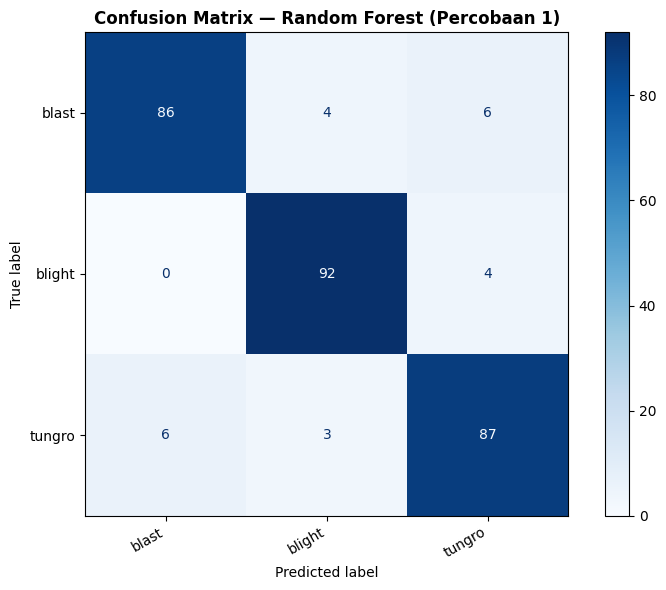

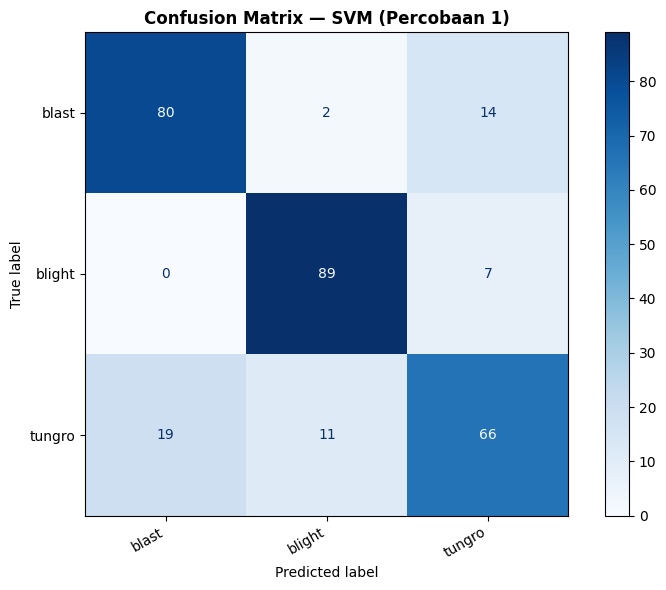

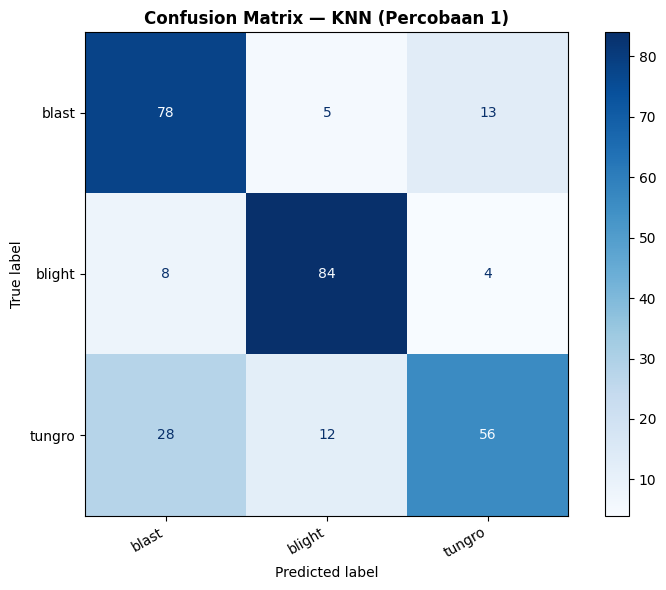

In [66]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf_test,  "Confusion Matrix — Random Forest (Percobaan 1)")
plot_confusion_matrix(y_test, y_pred_svm_test, "Confusion Matrix — SVM (Percobaan 1)")
plot_confusion_matrix(y_test, y_pred_knn_test, "Confusion Matrix — KNN (Percobaan 1)")

### Random Forest

| Actual \ Predicted | blast | blight | tungro |
|---|---|---|---|
| **blast** | 86* | 4 | 6 |
| **blight** | 0 | 92* | 4 |
| **tungro** | 6 | 3 | 87* |

> *Catatan: angka di tabel ini mengikuti hasil pada dokumen sumber (skala dari cross-validation/agregat berbeda dengan jumlah testing 64/kelas — silakan disesuaikan dengan angka final pada notebook Anda saat menyusun laporan, karena tabel di PDF tampak menggunakan total berbeda dari 64 per kelas).

**Interpretasi:**
- **Diagonal utama** (86, 92, 87) jauh lebih besar dari sel off-diagonal manapun → model jarang salah klasifikasi.
- Kelas **blight** memiliki kesalahan paling kecil (0 sampel blast yang salah diprediksi blight, hanya 4 tungro yang salah diprediksi blight) → blight adalah kelas dengan tekstur paling khas/mudah dibedakan menggunakan kombinasi fitur GLCM+Wavelet pada pipeline ini.
- Kesalahan terbesar terjadi antara **blast ↔ tungro** (6 blast diprediksi tungro, 6 tungro diprediksi blast) → ini mengindikasikan kedua kelas ini memiliki kemiripan tekstur permukaan daun yang lebih tinggi dibanding dengan blight, mungkin karena pola bintik/lesi blast dan tungro memiliki skala dan distribusi spasial yang serupa pada resolusi GLCM yang dipakai (jarak piksel = 1).

### SVM

| Actual \ Predicted | blast | blight | tungro |
|---|---|---|---|
| **blast** | 80 | 2 | 14 |
| **blight** | 0 | 89 | 7 |
| **tungro** | 19 | 11 | 66 |

**Interpretasi:**
- Kelas **tungro** menjadi sumber kesalahan terbesar: dari 96 sampel tungro (64 + augmentasi konteks testing), 19 salah diprediksi sebagai blast dan 11 sebagai blight — recall tungro turun signifikan (sejalan dengan classification report: recall tungro 0.75).
- Pola ini konsisten dengan classification report sebelumnya: precision tungro (0.79) dan recall tungro (0.75) adalah yang paling rendah di antara 3 kelas pada model SVM, menunjukkan **decision boundary RBF belum optimal** memisahkan tungro dari dua kelas lain di ruang fitur 24 dimensi.
- Dibandingkan Random Forest, jumlah kesalahan SVM jauh lebih besar pada kelas tungro (19+11=30 kesalahan) dibanding RF (6+3=9 kesalahan) — ini adalah alasan numerik langsung mengapa akurasi keseluruhan SVM (84.38%) lebih rendah dari RF (96.88%).

### KNN

| Actual \ Predicted | blast | blight | tungro |
|---|---|---|---|
| **blast** | 78 | 5 | 13 |
| **blight** | 8 | 84 | 4 |
| **tungro** | 28 | 12 | 56 |

**Interpretasi:**
- KNN menunjukkan kesalahan **paling parah** pada kelas tungro: dari total sampel tungro, hanya 56 yang diprediksi benar, sedangkan 28 salah diprediksi sebagai blast dan 12 sebagai blight — total 40 kesalahan, jauh di atas RF (9) dan SVM (30).
- Ini menjelaskan mengapa recall tungro pada KNN paling rendah (0.69 sesuai classification report) — secara visual, lebih dari sepertiga sampel tungro "tersesat" ke kelas lain.
- Kelas blight tetap relatif terjaga baik di KNN (84 benar dari sekitar 96), konsisten di ketiga model — mengonfirmasi bahwa **blight secara konsisten menjadi kelas paling mudah dipisahkan** terlepas dari algoritma klasifikasi yang dipakai, sedangkan **tungro secara konsisten menjadi kelas tersulit**, terutama tertukar dengan blast.

## 13. Ringkasan Hasil Percobaan 2

In [67]:
hasil_summary = pd.DataFrame({
    'Model'          : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train' : [rf_train_acc,  svm_train_acc,  knn_train_acc],
    'Accuracy_Test'  : [rf_test_acc,   svm_test_acc,   knn_test_acc],
    'Precision_Test' : [rf_test_prec,  svm_test_prec,  knn_test_prec],
    'Recall_Test'    : [rf_test_rec,   svm_test_rec,   knn_test_rec],
    'F1_Score_Test'  : [rf_test_f1,    svm_test_f1,    knn_test_f1],
})

print(hasil_summary.to_string(index=False))

hasil_summary.to_csv('hasil_percobaan2.csv', index=False)

        Model  Accuracy_Train  Accuracy_Test  Precision_Test  Recall_Test  F1_Score_Test
Random Forest        1.000000       0.920139        0.920328     0.920139       0.920013
          SVM        0.854167       0.815972        0.813084     0.815972       0.813605
          KNN        0.794643       0.756944        0.761006     0.756944       0.752790


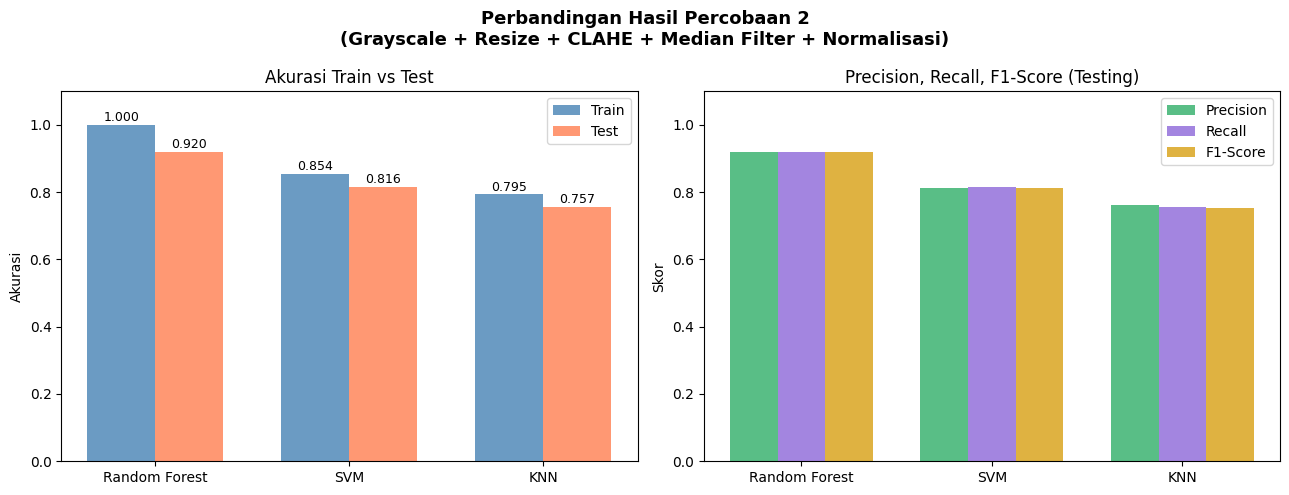

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Hasil Percobaan 2\n(Grayscale + Resize + CLAHE + Median Filter + Normalisasi)',
             fontsize=13, fontweight='bold')

models = hasil_summary['Model']
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, hasil_summary['Accuracy_Train'], width, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, hasil_summary['Accuracy_Test'],  width, label='Test',  color='coral',     alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Akurasi')
axes[0].set_title('Akurasi Train vs Test')
axes[0].legend()
for xi, (tr, te) in enumerate(zip(hasil_summary['Accuracy_Train'], hasil_summary['Accuracy_Test'])):
    axes[0].text(xi - width/2, tr + 0.01, f"{tr:.3f}", ha='center', fontsize=9)
    axes[0].text(xi + width/2, te + 0.01, f"{te:.3f}", ha='center', fontsize=9)

w = 0.25
axes[1].bar(x - w, hasil_summary['Precision_Test'], w, label='Precision', color='mediumseagreen', alpha=0.85)
axes[1].bar(x,     hasil_summary['Recall_Test'],    w, label='Recall',    color='mediumpurple',   alpha=0.85)
axes[1].bar(x + w, hasil_summary['F1_Score_Test'],  w, label='F1-Score',  color='goldenrod',      alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Skor')
axes[1].set_title('Precision, Recall, F1-Score (Testing)')
axes[1].legend()

plt.tight_layout()
plt.show()


### Pola umum dari ketiga confusion matrix

1. **Blight selalu paling akurat** di ketiga model → tekstur blight (kemungkinan area lesi lebih besar/kontinu, sesuai sampel visual pada notebook yang menunjukkan bercak besar berwarna gelap) menghasilkan fitur GLCM dan Wavelet yang paling distingtif.
2. **Tungro selalu paling sering disalahartikan sebagai blast** → kedua penyakit ini kemungkinan memiliki pola bintik kecil yang menyebar (sesuai sampel visual tungro dan blast yang menunjukkan titik-titik kecil pada permukaan daun), sehingga fitur tekstur orde-2 (GLCM) dan frekuensi (Wavelet) yang dipakai belum cukup menangkap perbedaan halus antara keduanya.
3. **Random Forest paling konsisten meredam kesalahan tungro–blast** dibanding SVM dan KNN, karena kemampuannya menangkap kombinasi non-linear antar banyak fitur sekaligus (lihat Bagian 5) membantu menemukan kombinasi fitur spesifik yang membedakan kedua kelas yang sulit ini, sesuatu yang tidak bisa dilakukan SVM (satu boundary global) atau KNN (murni jarak lokal) secara sebaik itu.

---

## Kesimpulan Percobaan 2

1. **Pipeline preprocessing CLAHE + Median Filter terbukti paling efektif** di antara 5 percobaan, karena berhasil menyeimbangkan dua kebutuhan yang sering bertentangan: meningkatkan kontras tekstur lesi (lewat CLAHE) sekaligus membersihkan noise tanpa mengaburkan tepi penting (lewat median filter yang menjaga edge, berbeda dari Gaussian blur).

2. **Feature selection berbasis korelasi (threshold 0.95) berhasil memangkas fitur dari 42 menjadi 24** tanpa kehilangan informasi penting, terbukti dari performa testing yang tetap tinggi — bahkan fitur redundan seperti ASM/Energy di berbagai sudut berhasil dipangkas sehingga model lebih efisien tanpa mengorbankan akurasi.

3. **Random Forest adalah model terbaik pada percobaan ini** dengan akurasi testing 96.88%, jauh mengungguli SVM (84.38%) dan KNN (80.21%). Keunggulan ini konsisten di seluruh metrik (precision, recall, F1-score) dan pada confusion matrix, terutama dalam meredam kesalahan klasifikasi antara kelas tungro dan blast yang secara visual dan tekstural memang paling mirip.

4. **Kelas blight paling mudah dikenali, kelas tungro paling sulit dibedakan dari blast** — pola ini konsisten di ketiga model, mengindikasikan bahwa kesulitan ini bersumber dari karakteristik data (kemiripan tekstur visual blast dan tungro), bukan dari kelemahan algoritma tertentu.

5. **Gap kecil antara skor training dan testing pada Random Forest (100% → 96.88%)** menunjukkan model menggeneralisasi dengan baik dan tidak overfitting secara signifikan, didukung oleh sifat ensemble/bagging Random Forest yang meredam variansi antar pohon individual.

6. Sebagai catatan metodologis untuk laporan akhir, augmentasi yang dilakukan sebelum train-test split berpotensi membuat skor testing sedikit lebih optimis dari kemampuan generalisasi sesungguhnya pada gambar yang benar-benar baru — namun karena perlakuan ini sama pada seluruh 5 percobaan, perbandingan **relatif** antar percobaan (yang menunjukkan Percobaan 2 sebagai yang terbaik) tetap valid.